## Import Libraries

In [231]:
!pip install openmeteo-requests requests-cache retry-requests
# installation of packages for open-meteo API


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [232]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import ast

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Functions

### Function for Calling the Historical Weather API

In [233]:
def get_weather_info(row, lat_col, long_col, date_col):

  # Set up the Open-Meteo API client with cache and retry on error
  cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
  retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
  openmeteo = openmeteo_requests.Client(session = retry_session)

  latitude = row[lat_col]
  longitude = row[long_col]
  # Use the date from the FL_DATE column for the API call
  flight_date = pd.to_datetime(row[date_col]).strftime('%Y-%m-%d')
  start_date = flight_date
  end_date = flight_date


  url = "https://archive-api.open-meteo.com/v1/archive"
  params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": ["weather_code", "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min", "apparent_temperature_mean", "apparent_temperature_max", "apparent_temperature_min", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant", "shortwave_radiation_sum", "et0_fao_evapotranspiration", "sunrise", "sunset", "daylight_duration", "sunshine_duration", "precipitation_sum", "rain_sum", "snowfall_sum", "precipitation_hours"],
    "timezone": "auto",
  }
  responses = openmeteo.weather_api(url, params=params)
  response = responses[0]

  daily_data = response.Daily()


  for i in range(len(params['daily'])):
    row[params['daily'][i]] = daily_data.Variables(i).ValuesAsNumpy()

  return row

### Function for Fixing Data Types - Extracting the First Float

In [234]:
def extract_first_float(val):
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            lst = ast.literal_eval(val)
            if isinstance(lst, list) and len(lst) == 1:
                return float(lst[0])
        except Exception:
            return np.nan
    # If it's already a list
    if isinstance(val, list) and len(val) == 1:
        return float(val[0])
    return val

# Exploration of Delays Data Set

In [235]:
delays_df = pd.read_csv('Data/delays_by_flight.csv')

In [236]:
delays_df.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,DEP_DEL15,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,WEATHER_DELAY
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
5,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14761,SFB,"Sanford, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
6,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
7,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
8,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
9,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN


In [237]:
delays_df.columns.values

array(['FL_DATE', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME',
       'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST', 'DEST_CITY_NAME',
       'DEST_STATE_NM', 'DEP_DELAY_NEW', 'DEP_DEL15', 'ARR_DELAY_NEW',
       'ARR_DEL15', 'CANCELLED', 'WEATHER_DELAY'], dtype=object)

In [238]:
delays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   FL_DATE            539747 non-null  object 
 1   ORIGIN_AIRPORT_ID  539747 non-null  int64  
 2   ORIGIN             539747 non-null  object 
 3   ORIGIN_CITY_NAME   539747 non-null  object 
 4   ORIGIN_STATE_NM    539747 non-null  object 
 5   DEST_AIRPORT_ID    539747 non-null  int64  
 6   DEST               539747 non-null  object 
 7   DEST_CITY_NAME     539747 non-null  object 
 8   DEST_STATE_NM      539747 non-null  object 
 9   DEP_DELAY_NEW      523824 non-null  float64
 10  DEP_DEL15          523824 non-null  float64
 11  ARR_DELAY_NEW      522269 non-null  float64
 12  ARR_DEL15          522269 non-null  float64
 13  CANCELLED          539747 non-null  int64  
 14  WEATHER_DELAY      98130 non-null   float64
dtypes: float64(5), int64(3), object(7)
memory usage: 61

In [239]:
delays_df.describe()


,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,DEP_DELAY_NEW,DEP_DEL15,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,WEATHER_DELAY
count,539747.000000,539747.000000,523824.000000,523824.000000,522269.000000,522269.000000,539747.000000,98130.000000
mean,12666.054390,12665.853333,14.090695,0.182619,14.218872,0.187892,0.030222,6.419770
std,1527.227187,1527.232740,53.192419,0.386354,53.054696,0.390626,0.171197,47.503613
min,10135.000000,10135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11292.000000,11292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12889.000000,12889.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14057.000000,14057.000000,6.000000,0.000000,7.000000,0.000000,0.000000,0.000000
max,16869.000000,16869.000000,3298.000000,1.000000,3282.000000,1.000000,1.000000,1765.000000


#### Mean Weather Delay in Minutes for Flights Delayed by Weather

In [240]:
mean_weather_delay = delays_df[delays_df['WEATHER_DELAY'] != 0]['WEATHER_DELAY'].mean()
print(mean_weather_delay)

81.44434389140271


#### Total Number of Delayed Flights
##### This means out of 539747 flights, 98130 were over 15 minutes late to arrive

In [241]:
total = delays_df.ARR_DEL15.sum()
print(total)

98130.0


In [242]:
delays_df.ARR_DEL15.value_counts()

ARR_DEL15
0.0    424139
1.0     98130
Name: count, dtype: int64

#### Heatmap to Show Null values

<Axes: >

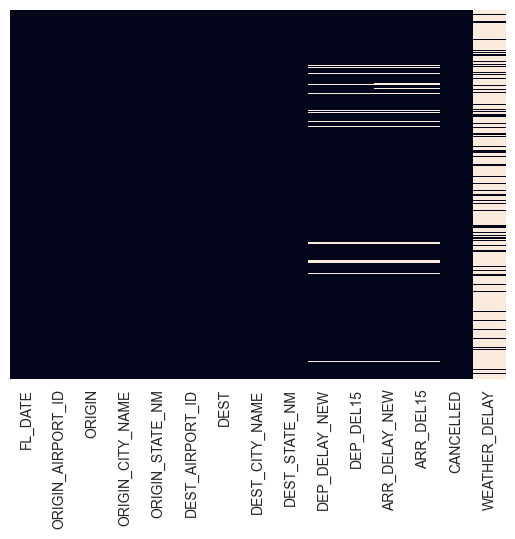

In [243]:
sns.heatmap(delays_df.isnull(),cbar=False,yticklabels=False)

#### Heatmap to Show Correlation Between Numerical Columns in the Dataframe

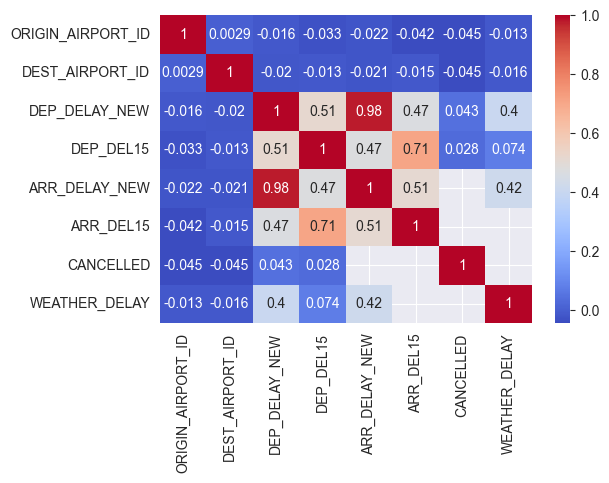

In [244]:
numeric_df = delays_df.select_dtypes(include='number')

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


#### Top 10 States for Flight Delays based on Origin Airport

Text(0.5, 1.0, 'Chart showing top 10 States for delays over 15 minutes')

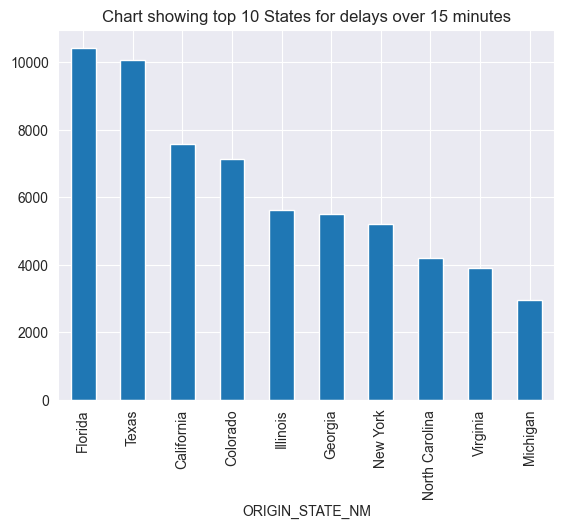

In [245]:
top_airports = delays_df.groupby('ORIGIN_STATE_NM')['ARR_DEL15'].sum().sort_values(ascending=False).head(10)
top_airports.plot(kind='bar')
plt.title('Chart showing top 10 States for delays over 15 minutes')

#### Top 10 States for Flight Delays based on Destination Airport

Text(0.5, 1.0, 'Chart showing top 10 States for delays over 15 minutes')

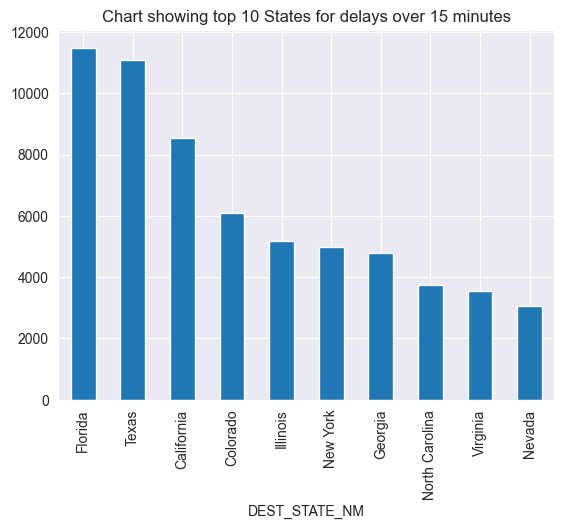

In [246]:
top_airports = delays_df.groupby('DEST_STATE_NM')['ARR_DEL15'].sum().sort_values(ascending=False).head(10)
top_airports.plot(kind='bar')
plt.title('Chart showing top 10 States for delays over 15 minutes')

# Similar states are top for arrival delays when flights leave from there and arrive there- may be due to weather?

#### Histogram of Weather Delays

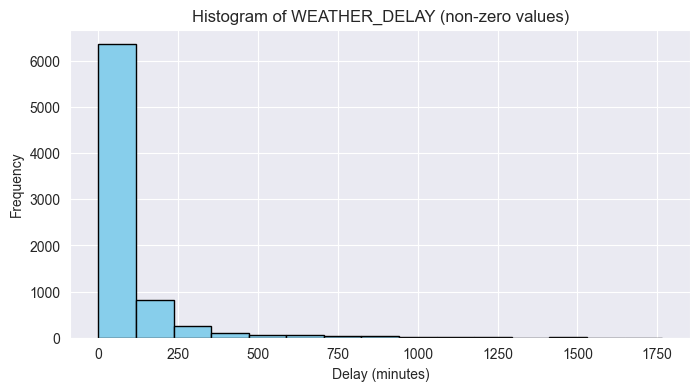

In [247]:
weather_data_nonzero = delays_df.loc[delays_df['WEATHER_DELAY'] != 0, 'WEATHER_DELAY']

plt.figure(figsize=(8,4))
plt.hist(weather_data_nonzero, bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of WEATHER_DELAY (non-zero values)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()
weather_data_nonzero = delays_df.loc[delays_df['WEATHER_DELAY'] != 0, 'WEATHER_DELAY']



## Create a Dataframe of the Airports Data

In [248]:
airports_path = 'Data/airports.csv'

In [249]:
airports_df = pd.read_csv(airports_path)

In [250]:
airports_df.head(10)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
5,ACK,Nantucket Memorial Airport,Nantucket,MA,USA,41.25305,-70.06018
6,ACT,Waco Regional Airport,Waco,TX,USA,31.61129,-97.23052
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
8,ACY,Atlantic City International Airport,Atlantic City,NJ,USA,39.45758,-74.57717
9,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603


## Merge the Delays Data with the Airports Data

### Origin
##### Merge the longitude and latitude of the origin airport to the delays_df

In [251]:
overall_df_merged = delays_df.merge(airports_df, left_on='ORIGIN', right_on='IATA_CODE', how='left')

In [252]:
overall_df_merged.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,ARR_DEL15,CANCELLED,WEATHER_DELAY,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
5,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14761,SFB,"Sanford, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
6,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
7,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
8,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
9,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819


### Destination
##### Merge the longitude and latitude of the destination airport to the delays_df

In [253]:
overall_df_merged = overall_df_merged.merge(airports_df, left_on='DEST', right_on='IATA_CODE', how='left', suffixes=('_ORIGIN', '_DEST'))

In [254]:
overall_df_merged

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,COUNTRY_ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,...,USA,40.65236,-75.4404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,...,USA,40.65236,-75.4404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539742,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,20.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539743,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,89.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539744,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,116.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539745,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,13487,MSP,"Minneapolis, MN",Minnesota,0.0,...,NaN,NaN,NaN,MSP,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.88055,-93.21692


## Filter the Dataset to a Manageable Size for the Historical Weather API

##### There is a daily limit of 10000 calls to the API

##### Keep only the delayed flights data

In [255]:
overall_df_merged_delayed = overall_df_merged[overall_df_merged['ARR_DEL15'] == 1.0]

In [256]:
overall_df_merged_delayed.shape

(98130, 29)

In [257]:
overall_df_merged_delayed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98130 entries, 20 to 539744
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            98130 non-null  object 
 1   ORIGIN_AIRPORT_ID  98130 non-null  int64  
 2   ORIGIN             98130 non-null  object 
 3   ORIGIN_CITY_NAME   98130 non-null  object 
 4   ORIGIN_STATE_NM    98130 non-null  object 
 5   DEST_AIRPORT_ID    98130 non-null  int64  
 6   DEST               98130 non-null  object 
 7   DEST_CITY_NAME     98130 non-null  object 
 8   DEST_STATE_NM      98130 non-null  object 
 9   DEP_DELAY_NEW      98130 non-null  float64
 10  DEP_DEL15          98130 non-null  float64
 11  ARR_DELAY_NEW      98130 non-null  float64
 12  ARR_DEL15          98130 non-null  float64
 13  CANCELLED          98130 non-null  int64  
 14  WEATHER_DELAY      98130 non-null  float64
 15  IATA_CODE_ORIGIN   97008 non-null  object 
 16  AIRPORT_ORIGIN     97008 

##### Remove any rows with N/A values - we can only use the flights for which we have the longitude and latitude for both origin and destination airports

In [258]:
overall_df_merged_delayed = overall_df_merged_delayed.dropna()

In [259]:
overall_df_merged_delayed.shape

(95787, 29)

##### Keep only the rows for Florida as the origin
##### Based on the previous analysis Florida has the most flight delays

In [260]:
overall_df_merged_delayed = overall_df_merged_delayed[overall_df_merged_delayed['ORIGIN_STATE_NM'] == 'Florida']

In [261]:
overall_df_merged_delayed.shape

(9883, 29)

In [262]:
overall_df_merged_delayed.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,COUNTRY_ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
3256,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,USA,29.17992,-81.05806,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6171,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,USA,24.55611,-81.75956,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6172,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,USA,24.55611,-81.75956,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6174,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,USA,24.55611,-81.75956,DCA,Ronald Reagan Washington National Airport,Arlington,VA,USA,38.85208,-77.03772
6182,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,USA,24.55611,-81.75956,MIA,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
6187,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,14100,PHL,"Philadelphia, PA",Pennsylvania,32.0,...,USA,24.55611,-81.75956,PHL,Philadelphia International Airport,Philadelphia,PA,USA,39.87195,-75.24114
6265,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,0.0,...,USA,26.07258,-80.15275,ATL,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.64044,-84.42694
6276,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,243.0,...,USA,26.07258,-80.15275,ATL,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.64044,-84.42694
6279,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,75.0,...,USA,26.07258,-80.15275,AVL,Asheville Regional Airport,Asheville,NC,USA,35.43619,-82.54181
6280,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,291.0,...,USA,26.07258,-80.15275,AVL,Asheville Regional Airport,Asheville,NC,USA,35.43619,-82.54181


## Call the Historical Weather API for the Florida data

### Origin Data
##### Get each unique combination of flight date, origin, latitude and longitude

In [263]:
grouped_date_origin = overall_df_merged_delayed[['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN']].drop_duplicates()

In [264]:
grouped_date_origin

,FL_DATE,ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN
3256,01/01/2025 00:00,DAB,29.17992,-81.05806
6171,01/01/2025 00:00,EYW,24.55611,-81.75956
6265,01/01/2025 00:00,FLL,26.07258,-80.15275
7804,01/01/2025 00:00,JAX,30.49406,-81.68786
9683,01/01/2025 00:00,MCO,28.42889,-81.31603
...,...,...,...,...
536745,1/31/2025 12:00:00 AM,RSW,26.53617,-81.75517
539018,1/31/2025 12:00:00 AM,SRQ,27.39533,-82.55411
539288,1/31/2025 12:00:00 AM,TLH,30.39653,-84.35033
539311,1/31/2025 12:00:00 AM,TPA,27.97547,-82.53325


#### API was called and data saved to avoid hitting API limit and needing to run every time. Lines of code are commented out so that calling the API doesn't auto run

In [265]:
# grouped_date_origin = grouped_date_origin.apply(get_weather_info, axis=1, args=('LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN', 'FL_DATE'))

In [266]:
# grouped_date_origin.to_csv('Data/grouped_date_origin_weather_florida.csv')

In [267]:
grouped_date_origin = pd.read_csv('Data/grouped_date_origin_weather_florida.csv')

In [268]:
grouped_date_origin.head()

,Unnamed: 0,FL_DATE,ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,3256,01/01/2025 00:00,DAB,29.17992,-81.05806,[3.],[16.194],[18.7565],[12.0065],[15.587325],...,[14.54],[2.298343],0,0,[37144.996],[33252.48],[0.],[0.],[0.],[0.]
1,6171,01/01/2025 00:00,EYW,24.55611,-81.75956,[3.],[21.925499],[23.163],[21.163],[23.675394],...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
2,6265,01/01/2025 00:00,FLL,26.07258,-80.15275,[51.],[21.942917],[25.5325],[19.432499],[24.044882],...,[15.16],[2.8054278],0,0,[37966.69],[33436.668],[0.1],[0.1],[0.],[1.]
3,7804,01/01/2025 00:00,JAX,30.49406,-81.68786,[1.],[13.960167],[18.1435],[9.4935],[11.701987],...,[14.08],[2.4897807],0,0,[36801.066],[32884.55],[0.],[0.],[0.],[0.]
4,9683,01/01/2025 00:00,MCO,28.42889,-81.31603,[3.],[17.906748],[20.863],[13.513],[17.813602],...,[14.67],[2.5929782],0,0,[37350.656],[33200.9],[0.],[0.],[0.],[0.]


### Destination Data
##### Get each unique combination of flight date, origin, latitude and longitude

In [269]:
grouped_date_destination = overall_df_merged_delayed[['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST']].drop_duplicates()

In [270]:
grouped_date_destination.head()

,FL_DATE,DEST,LATITUDE_DEST,LONGITUDE_DEST
3256,01/01/2025 00:00,CLT,35.21401,-80.94313
6174,01/01/2025 00:00,DCA,38.85208,-77.03772
6182,01/01/2025 00:00,MIA,25.79325,-80.29056
6187,01/01/2025 00:00,PHL,39.87195,-75.24114
6265,01/01/2025 00:00,ATL,33.64044,-84.42694


#### API was called and data saved to avoid hitting API limit and needing to run every time. Lines of code are commented out so that calling the API doesn't auto run

In [271]:
# grouped_date_destination = grouped_date_destination.apply(get_weather_info, axis=1, args=('LATITUDE_DEST', 'LONGITUDE_DEST', 'FL_DATE'))

In [272]:
# grouped_date_destination

In [273]:
# grouped_date_destination.to_csv('Data/grouped_date_destination_weather_florida.csv')

In [274]:
grouped_date_destination = pd.read_csv('Data/grouped_date_destination_weather_florida.csv')

In [275]:
grouped_date_destination.head()

,Unnamed: 0,FL_DATE,DEST,LATITUDE_DEST,LONGITUDE_DEST,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,3256,01/01/2025 00:00,CLT,35.21401,-80.94313,[1.],[7.935001],[11.085],[4.785],[3.5809011],...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
1,6174,01/01/2025 00:00,DCA,38.85208,-77.03772,[2.],[6.8800006],[8.842501],[4.1925],[2.3371618],...,[7.69],[1.5064157],0,0,[34233.156],[30449.094],[0.],[0.],[0.],[0.]
2,6182,01/01/2025 00:00,MIA,25.79325,-80.29056,[3.],[21.935087],[25.345499],[18.9455],[24.452215],...,[15.11],[2.6905723],0,0,[38037.36],[33106.91],[0.],[0.],[0.],[0.]
3,6187,01/01/2025 00:00,PHL,39.87195,-75.24114,[3.],[7.072333],[10.089],[4.139],[2.6699219],...,[6.68],[1.3925666],0,0,[33863.1],[25166.607],[0.],[0.],[0.],[0.]
4,6265,01/01/2025 00:00,ATL,33.64044,-84.42694,[3.],[6.600416],[10.0525],[3.4025],[2.3100054],...,[10.99],[1.7924072],0,0,[35896.18],[32267.57],[0.],[0.],[0.],[0.]


## Merge API Data for Origin and Destination Airports to the Main Florida Dataset

In [276]:
overall_df_merged_delayed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9883 entries, 3256 to 539684
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            9883 non-null   object 
 1   ORIGIN_AIRPORT_ID  9883 non-null   int64  
 2   ORIGIN             9883 non-null   object 
 3   ORIGIN_CITY_NAME   9883 non-null   object 
 4   ORIGIN_STATE_NM    9883 non-null   object 
 5   DEST_AIRPORT_ID    9883 non-null   int64  
 6   DEST               9883 non-null   object 
 7   DEST_CITY_NAME     9883 non-null   object 
 8   DEST_STATE_NM      9883 non-null   object 
 9   DEP_DELAY_NEW      9883 non-null   float64
 10  DEP_DEL15          9883 non-null   float64
 11  ARR_DELAY_NEW      9883 non-null   float64
 12  ARR_DEL15          9883 non-null   float64
 13  CANCELLED          9883 non-null   int64  
 14  WEATHER_DELAY      9883 non-null   float64
 15  IATA_CODE_ORIGIN   9883 non-null   object 
 16  AIRPORT_ORIGIN     9883 

#### Origin Data

In [277]:
florida_delays_weather_df = overall_df_merged_delayed.merge(grouped_date_origin, left_on=['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN'], right_on=['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN'], how='left')

In [278]:
florida_delays_weather_df.head()

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,[14.54],[2.298343],0,0,[37144.996],[33252.48],[0.],[0.],[0.],[0.]
1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]


#### Destination Data

In [279]:
florida_delays_weather_df = florida_delays_weather_df.merge(grouped_date_destination, left_on=['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST'], right_on=['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST'], how='left', suffixes=['_ORIGIN', '_DEST'])

In [280]:
florida_delays_weather_df.head()

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,shortwave_radiation_sum_DEST,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST
0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,[7.69],[1.5064157],0,0,[34233.156],[30449.094],[0.],[0.],[0.],[0.]
4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,[15.11],[2.6905723],0,0,[38037.36],[33106.91],[0.],[0.],[0.],[0.]


In [281]:
florida_delays_weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 71 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   FL_DATE                             9883 non-null   object 
 1   ORIGIN_AIRPORT_ID                   9883 non-null   int64  
 2   ORIGIN                              9883 non-null   object 
 3   ORIGIN_CITY_NAME                    9883 non-null   object 
 4   ORIGIN_STATE_NM                     9883 non-null   object 
 5   DEST_AIRPORT_ID                     9883 non-null   int64  
 6   DEST                                9883 non-null   object 
 7   DEST_CITY_NAME                      9883 non-null   object 
 8   DEST_STATE_NM                       9883 non-null   object 
 9   DEP_DELAY_NEW                       9883 non-null   float64
 10  DEP_DEL15                           9883 non-null   float64
 11  ARR_DELAY_NEW                       9883 no

##### Remove unwanted columns

In [282]:
florida_delays_weather_df.drop(['Unnamed: 0_ORIGIN', 'Unnamed: 0_DEST', 'IATA_CODE_ORIGIN', 'IATA_CODE_DEST'], axis=1, inplace=True)

###### writing the dataframe to a file has been commented out to not be overwritten

In [283]:
# florida_delays_weather_df.to_csv('Data/florida_delays_weather_data.csv')

## Clean the Newly Created Data

In [284]:
florida_delays = pd.read_csv('Data/florida_delays_weather_data.csv')
florida_delays.head()

,Unnamed: 0,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,...,shortwave_radiation_sum_DEST,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST
0,0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
1,1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
2,2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
3,3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,...,[7.69],[1.5064157],0,0,[34233.156],[30449.094],[0.],[0.],[0.],[0.]
4,4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,...,[15.11],[2.6905723],0,0,[38037.36],[33106.91],[0.],[0.],[0.],[0.]


In [285]:
florida_delays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 68 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          9883 non-null   int64  
 1   FL_DATE                             9883 non-null   object 
 2   ORIGIN_AIRPORT_ID                   9883 non-null   int64  
 3   ORIGIN                              9883 non-null   object 
 4   ORIGIN_CITY_NAME                    9883 non-null   object 
 5   ORIGIN_STATE_NM                     9883 non-null   object 
 6   DEST_AIRPORT_ID                     9883 non-null   int64  
 7   DEST                                9883 non-null   object 
 8   DEST_CITY_NAME                      9883 non-null   object 
 9   DEST_STATE_NM                       9883 non-null   object 
 10  DEP_DELAY_NEW                       9883 non-null   float64
 11  DEP_DEL15                           9883 no

#### Extract the First Float and Convert it to Numeric

In [286]:
for col in florida_delays.columns:
    florida_delays[col] = florida_delays[col].apply(extract_first_float)
    # Try to convert to numeric if possible
    florida_delays[col] = pd.to_numeric(florida_delays[col], errors='coerce')

#### Write the Newly Cleaned Data to a File
###### commented out to avoid rewriting

In [287]:
# florida_delays.to_csv("florida_delays_weather_data_cleaned.csv", index=False)

In [288]:
cleanedFloridaWeather = pd.read_csv('Data/florida_delays_weather_data_cleaned.csv')
cleanedFloridaWeather.head()

,Unnamed: 0,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,...,shortwave_radiation_sum_DEST,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST
0,0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,11.43,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0
1,1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,11.43,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0
2,2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,11.43,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0
3,3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,...,7.69,1.506416,0,0,34233.156,30449.094,0.0,0.0,0.0,0.0
4,4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,...,15.11,2.690572,0,0,38037.360,33106.910,0.0,0.0,0.0,0.0


#### Create a New Binary Column Called 'WEATHER_BINARY'
###### 0 = Not delayed by weather, 1 = Delayed by weather

In [289]:
cleanedFloridaWeather['WEATHER_DELAY_BINARY'] = cleanedFloridaWeather['WEATHER_DELAY'].apply(
    lambda x: 1 if pd.notnull(x) and x > 0 else 0
)

#### Write the New Data to a File
###### commented out to avoid rewriting

In [290]:
# cleanedFloridaWeather.to_csv('Data/weather_delay_binary.csv', index=False)

## Explore the Florida Weather Delays Dataset

In [291]:
florida_delays_binary = pd.read_csv('Data/weather_delay_binary.csv')

In [292]:
florida_delays_binary.head()

,Unnamed: 0,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,...,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST,WEATHER_DELAY_BINARY
0,0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0,0
1,1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0,0
2,2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,...,2.234588,0,0,35426.990,32053.158,0.0,0.0,0.0,0.0,0
3,3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,...,1.506416,0,0,34233.156,30449.094,0.0,0.0,0.0,0.0,0
4,4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,...,2.690572,0,0,38037.360,33106.910,0.0,0.0,0.0,0.0,0


In [293]:
florida_delays_binary.describe()

,Unnamed: 0,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,DEP_DELAY_NEW,DEP_DEL15,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,WEATHER_DELAY,LATITUDE_ORIGIN,...,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST,WEATHER_DELAY_BINARY
count,9883.000000,9883.000000,9883.000000,9883.000000,9883.000000,9883.000000,9883.0,9883.0,9883.000000,9883.000000,...,9883.000000,9883.0,9883.0,9883.000000,9883.000000,9883.000000,9883.000000,9883.000000,9883.000000,9883.000000
mean,4941.000000,13380.782859,12266.309521,64.224223,0.808661,64.971567,1.0,0.0,1.978144,27.189376,...,1.326637,0.0,0.0,35597.333092,23195.109847,2.074593,1.506476,0.398851,3.301123,0.021653
std,2853.120689,1144.766592,1455.055610,92.054870,0.393375,89.075178,0.0,0.0,31.665298,1.418588,...,0.840166,0.0,0.0,1766.374161,11811.003420,6.152644,5.938801,1.277674,5.119399,0.145556
min,0.000000,11252.000000,10135.000000,0.000000,0.000000,15.000000,1.0,0.0,0.000000,24.556110,...,0.221319,0.0,0.0,30771.898000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2470.500000,13204.000000,11057.000000,21.000000,1.000000,23.000000,1.0,0.0,0.000000,26.072580,...,0.720447,0.0,0.0,34160.152000,16400.801500,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4941.000000,13303.000000,11995.000000,41.000000,1.000000,38.000000,1.0,0.0,0.000000,26.683160,...,1.155385,0.0,0.0,35470.184000,28883.500000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7411.500000,14027.000000,13303.000000,74.000000,1.000000,72.000000,1.0,0.0,0.000000,28.428890,...,1.678131,0.0,0.0,36780.254000,32206.975000,1.600000,0.100000,0.070000,6.000000,0.000000
max,9882.000000,15624.000000,15919.000000,1493.000000,1.000000,1476.000000,1.0,0.0,1212.000000,30.494060,...,5.604854,0.0,0.0,40923.527000,38270.234000,68.400000,68.400000,15.610001,24.000000,1.000000


In [294]:
florida_delays_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 69 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          9883 non-null   int64  
 1   FL_DATE                             9883 non-null   object 
 2   ORIGIN_AIRPORT_ID                   9883 non-null   int64  
 3   ORIGIN                              9883 non-null   object 
 4   ORIGIN_CITY_NAME                    9883 non-null   object 
 5   ORIGIN_STATE_NM                     9883 non-null   object 
 6   DEST_AIRPORT_ID                     9883 non-null   int64  
 7   DEST                                9883 non-null   object 
 8   DEST_CITY_NAME                      9883 non-null   object 
 9   DEST_STATE_NM                       9883 non-null   object 
 10  DEP_DELAY_NEW                       9883 non-null   float64
 11  DEP_DEL15                           9883 no

In [295]:
print(florida_delays_binary.columns.tolist())

['Unnamed: 0', 'FL_DATE', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_NM', 'DEP_DELAY_NEW', 'DEP_DEL15', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'WEATHER_DELAY', 'AIRPORT_ORIGIN', 'CITY_ORIGIN', 'STATE_ORIGIN', 'COUNTRY_ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN', 'AIRPORT_DEST', 'CITY_DEST', 'STATE_DEST', 'COUNTRY_DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST', 'weather_code_ORIGIN', 'temperature_2m_mean_ORIGIN', 'temperature_2m_max_ORIGIN', 'temperature_2m_min_ORIGIN', 'apparent_temperature_mean_ORIGIN', 'apparent_temperature_max_ORIGIN', 'apparent_temperature_min_ORIGIN', 'wind_speed_10m_max_ORIGIN', 'wind_gusts_10m_max_ORIGIN', 'wind_direction_10m_dominant_ORIGIN', 'shortwave_radiation_sum_ORIGIN', 'et0_fao_evapotranspiration_ORIGIN', 'sunrise_ORIGIN', 'sunset_ORIGIN', 'daylight_duration_ORIGIN', 'sunshine_duration_ORIGIN', 'precipitation_sum_ORIGIN', 'rain_sum_ORIGIN', 'snowfall_sum_ORIGIN', 'precip

#### Frequency of Flights Delayed (1) and Not Delayed (0) by Weather

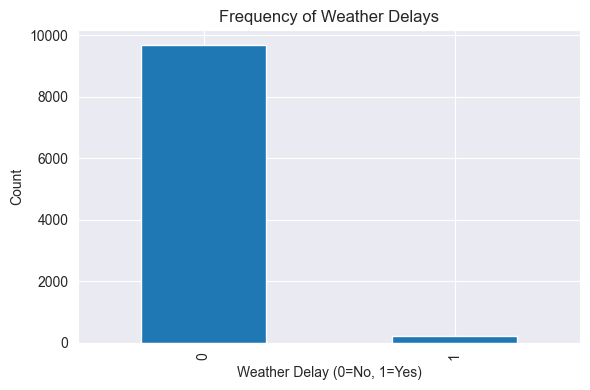

In [296]:
plt.figure(figsize=(6,4))
florida_delays_binary['WEATHER_DELAY_BINARY'].value_counts().plot(kind='bar')
plt.title('Frequency of Weather Delays')
plt.xlabel('Weather Delay (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Average Weather Delay by Airport

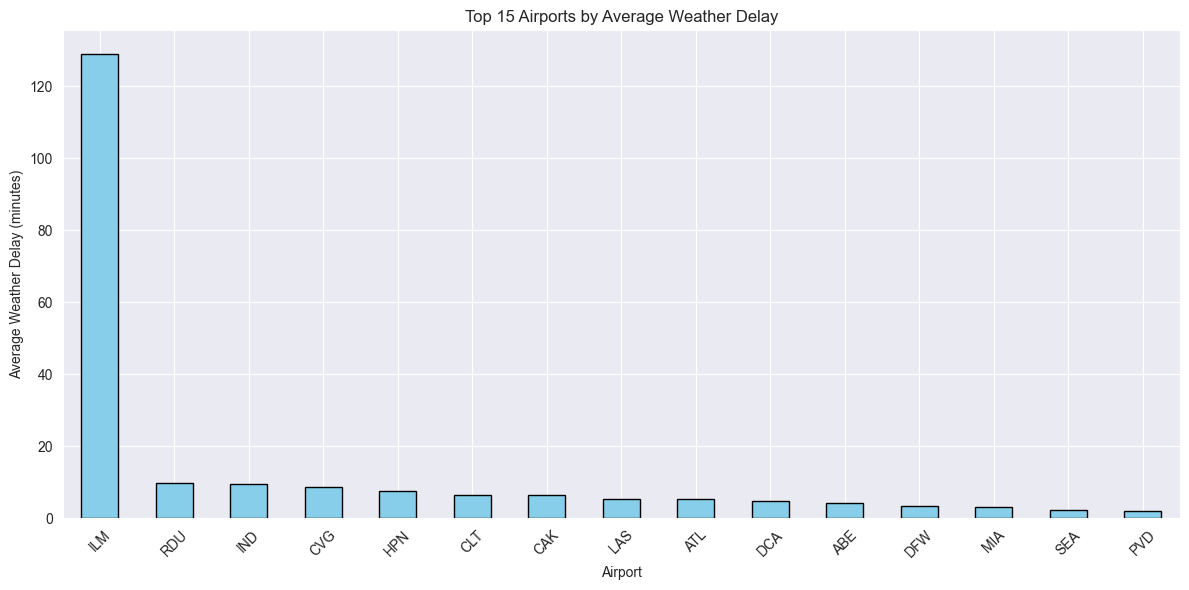

In [297]:
# Calculate average weather delay by airport and select top 15
avg_delay_by_airport = florida_delays_binary.groupby('DEST')['WEATHER_DELAY'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
avg_delay_by_airport.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 15 Airports by Average Weather Delay')
plt.xlabel('Airport')
plt.ylabel('Average Weather Delay (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Proportion of Flights Delayed and not Delayed

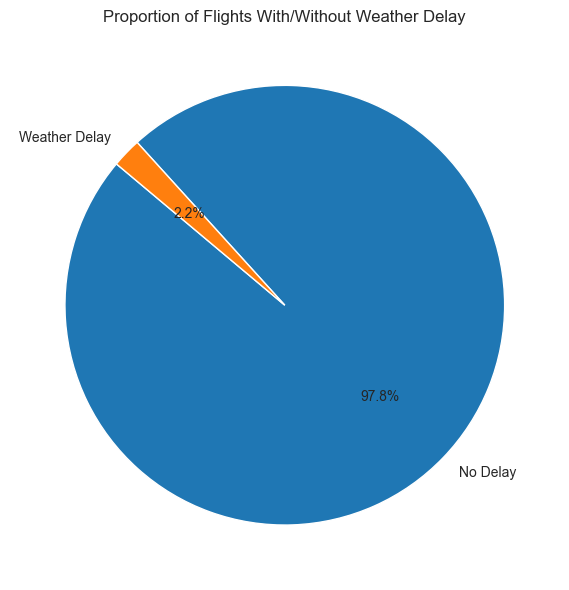

In [298]:
counts = florida_delays_binary['WEATHER_DELAY_BINARY'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=['No Delay', 'Weather Delay'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Flights With/Without Weather Delay')
plt.tight_layout()
plt.show()

## Predicting Delays Based on Weather Data

#### Prepare the Data

In [299]:
df = florida_delays_binary.drop(["DEP_DELAY_NEW", "ARR_DELAY_NEW", "ARR_DEL15", "WEATHER_DELAY"], axis=1)


y = df["WEATHER_DELAY_BINARY"]
X = df.drop(["WEATHER_DELAY_BINARY", "FL_DATE"], axis=1)

#### Create Training and Test sets

In [300]:
# this converts categorical values to "numerical" values using one hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Decision Tree Classifier

#### Train the Model

In [301]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Predict the Training Set

In [302]:
y_pred_dt = dt_model.predict(X_test)

#### Calculate accuracy

In [303]:
print('Accuracy Score:', accuracy_score(y_test, y_pred_dt))

Accuracy Score: 0.9615579160343956


#### Confusion Matrix

In [304]:
print(confusion_matrix(y_test, y_pred_dt))

[[1889   45]
 [  31   12]]


### Random Forest Classifier

#### Train the Model

In [305]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rd = rf_model.predict(X_test)

#### Accuracy and Confusion Matrix

Random Forest Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1934
           1       0.28      0.21      0.24        43

    accuracy                           0.97      1977
   macro avg       0.63      0.60      0.61      1977
weighted avg       0.97      0.97      0.97      1977



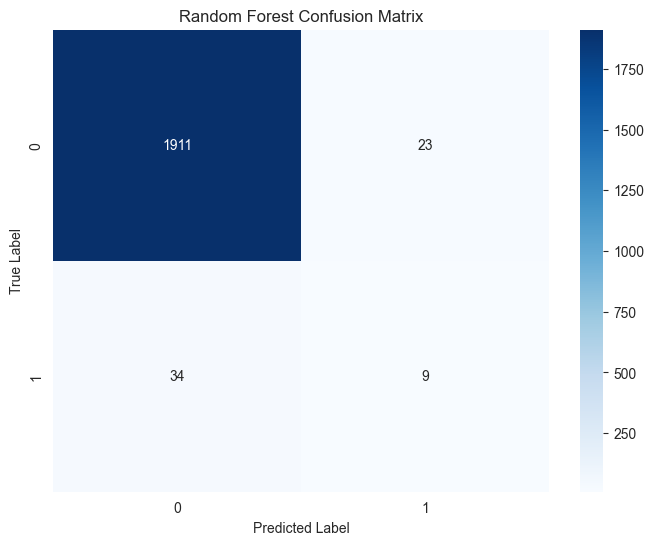

In [306]:
accuracy = accuracy_score(y_test, y_pred_rd)
print(f"Random Forest Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_rd))

cm = confusion_matrix(y_test, y_pred_rd)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### Compare Train and Test Accuracies

In [307]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9711684370257967


#### Calculate Feature Importance

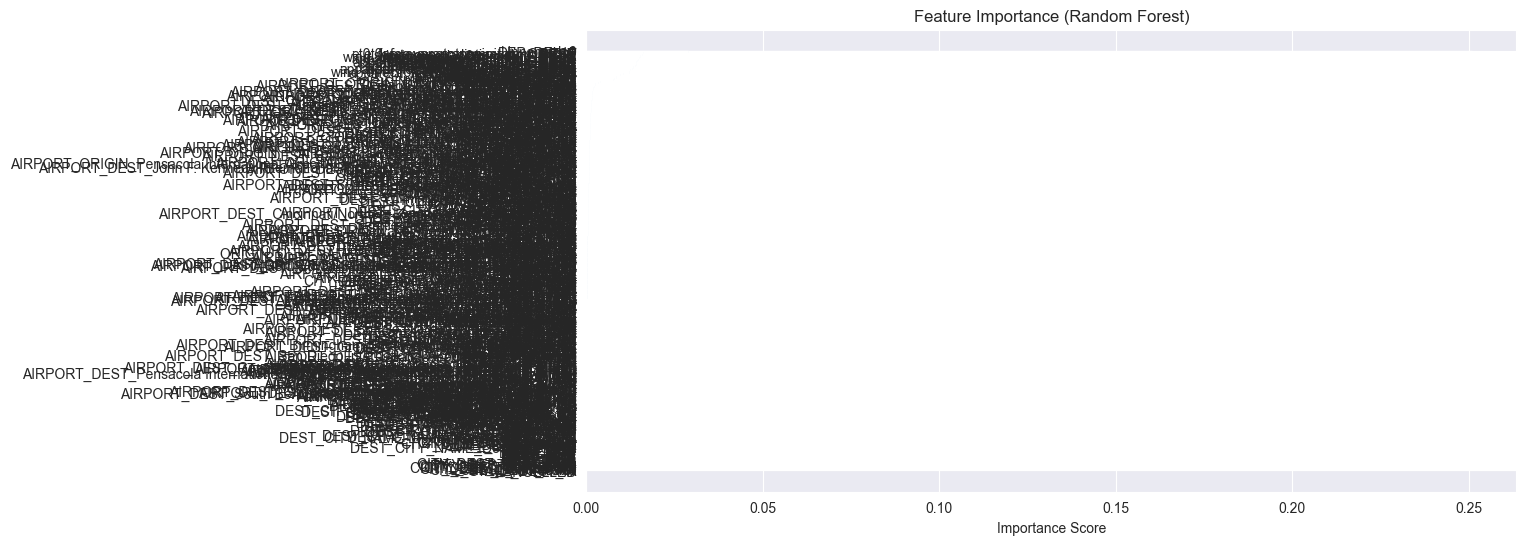

In [308]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'feature': feature_names,'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance (Random Forest)")
plt.show()